In [2]:
import pandas as pd
import numpy as np

# import the decision tree library from the scikit learn
import sklearn.tree as tree
from sklearn.tree import DecisionTreeClassifier
# for training and testing
from sklearn.model_selection import train_test_split
# library for calculating accuracy of the model
from sklearn.metrics import accuracy_score

#import the merged dataset from github
fullData = pd.read_csv("https://raw.githubusercontent.com/causeyca21/CSC442Group/refs/heads/main/merged_data.csv")
fullData.head()

,gvkey,tic,act,at,capx,che,cogs,ib,pi,revt,...,opt_unex_unexer_est_val,othcomp,salary,stock_awards,stock_unvest_val,tdc1,tdc2,total_sec,Stock as % of total compensation,Options as % of total compensation
0,1004,AIR,1097.900,1833.100,29.500,81.800,1591.300,89.800,121.200,1990.600,...,1684.328,482.257,1050.000,3272.152,13379.485,7865.228,12846.484,7865.450,0.416028,0.737331
1,1075,PNW,1926.967,24661.153,1889.934,4.955,3077.308,501.557,595.693,4695.991,...,0.000,34.831,1125.000,5028.405,3237.829,3753.703,3753.703,9322.192,1.339585,0.000000
2,1161,AMD,16768.000,67885.000,546.000,5773.000,10833.000,854.000,508.000,22680.000,...,0.000,28.711,1200.000,21848.258,9531.088,8500.023,123065.368,30348.281,2.570376,14.165121
3,1209,APD,5200.500,32002.500,4626.400,1949.200,7474.700,2292.800,2882.400,12600.000,...,0.000,401.795,1350.000,17074.629,18076.385,9994.108,9994.108,22078.099,1.708470,0.000000
4,1230,ALK,2705.000,14613.000,1494.000,1791.000,8106.000,235.000,323.000,10426.000,...,0.000,386.446,637.692,7969.932,0.000,8570.214,8570.214,10313.054,0.929957,0.000000


In [3]:
fullData.info

<bound method DataFrame.info of        gvkey   tic        act         at      capx       che       cogs  \
0       1004   AIR   1097.900   1833.100    29.500    81.800   1591.300   
1       1075   PNW   1926.967  24661.153  1889.934     4.955   3077.308   
2       1161   AMD  16768.000  67885.000   546.000  5773.000  10833.000   
3       1209   APD   5200.500  32002.500  4626.400  1949.200   7474.700   
4       1230   ALK   2705.000  14613.000  1494.000  1791.000   8106.000   
...      ...   ...        ...        ...       ...       ...        ...   
1147  264193  SNDR   1110.900   4557.200   807.600   159.600   4668.400   
1148  264416  UCTT    893.200   1867.700    75.800   307.000   1411.100   
1149  287462    FF    290.546    367.081     6.022   220.189    316.888   
1150  317264   LPG    236.299   1708.914    68.785   148.797     98.309   
1151  328795   ACA    912.000   3577.900   203.500   104.800   1709.600   

            ib        pi       revt  ...  opt_unex_unexer_est_val  othcomp  \
0       89.800   121.200   1990.600  ...                 1684.328  482.257   
1      501.557   595.693   4695.991  ...                    0.000   34.831   
2      854.000   508.000  22680.000  ...                    0.000   28.711   
3     2292.800  2882.400  12600.000  ...                    0.000  401.795   
4      235.000   323.000  10426.000  ...                    0.000  386.446   
...        ...       ...        ...  ...                      ...      ...   
1147   238.500   306.100   5498.900  ...                  216.553  149.056   
1148   -31.100   -11.300   1734.500  ...                    0.000   11.997   
1149    37.382    37.383    368.250  ...                    0.000   51.000   
1150   172.444   172.444    392.151  ...                    0.000    9.900   
1151   159.200   195.900   2307.900  ...                    0.000   20.770   

        salary  stock_awards  stock_unvest_val      tdc1        tdc2  \
0     1050.000      3272.152         13379.485  7865.228   12846.484   
1     1125.000      5028.405          3237.829  3753.703    3753.703   
2     1200.000     21848.258          9531.088  8500.023  123065.368   
3     1350.000     17074.629         18076.385  9994.108    9994.108   
4      637.692      7969.932             0.000  8570.214    8570.214   
...        ...           ...               ...       ...         ...   
1147   941.667      4703.533           268.218  1090.723    1090.723   
1148   736.538      3507.146          2986.943  5043.765    5043.765   
1149   442.000         0.000             0.000   699.000     699.000   
1150   650.000      2381.285          3095.991  1914.900    1914.900   
1151   980.500      4189.222          9991.319  2284.745    2284.745   

      total_sec  Stock as % of total compensation  \
0      7865.450                          0.416028   
1      9322.192                          1.339585   
2     30348.281                          2.570376   
3     22078.099                          1.708470   
4     10313.054                          0.929957   
...         ...                               ...   
1147   5794.256                          4.312308   
1148   5043.765                          0.695343   
1149    699.000                          0.000000   
1150   4296.185                          1.243556   
1151   6474.120                          1.833562   

     Options as % of total compensation  
0                              0.737331  
1                              0.000000  
2                             14.165121  
3                              0.000000  
4                              0.000000  
...                                 ...  
1147                           0.000000  
1148                           0.000000  
1149                           0.000000  
1150                           0.000000  
1151                           0.000000  

[1152 rows x 34 columns]>

In [4]:
fullData['Total Income Taxes as % of pretax income'].describe()

,Total Income Taxes as % of pretax income
count,1152.000000
mean,0.194361
std,2.284329
min,-32.937500
25%,0.110772
50%,0.208466
75%,0.252199
max,64.023569


In [5]:
# Add a categorical column for the decision tree to categorize companies as high or low income tax
# 0 = less than 15%
# 1 = 15-20%
# 2 = 20-25%
# 3 = 25%+
fullData['income_tax_category'] = fullData['Total Income Taxes as % of pretax income'].apply(lambda x: 0 if x < .15 else (1 if x < .20 else (2 if x < .25 else 3)))
fullData.head()

,gvkey,tic,act,at,capx,che,cogs,ib,pi,revt,...,othcomp,salary,stock_awards,stock_unvest_val,tdc1,tdc2,total_sec,Stock as % of total compensation,Options as % of total compensation,income_tax_category
0,1004,AIR,1097.900,1833.100,29.500,81.800,1591.300,89.800,121.200,1990.600,...,482.257,1050.000,3272.152,13379.485,7865.228,12846.484,7865.450,0.416028,0.737331,3
1,1075,PNW,1926.967,24661.153,1889.934,4.955,3077.308,501.557,595.693,4695.991,...,34.831,1125.000,5028.405,3237.829,3753.703,3753.703,9322.192,1.339585,0.000000,0
2,1161,AMD,16768.000,67885.000,546.000,5773.000,10833.000,854.000,508.000,22680.000,...,28.711,1200.000,21848.258,9531.088,8500.023,123065.368,30348.281,2.570376,14.165121,0
3,1209,APD,5200.500,32002.500,4626.400,1949.200,7474.700,2292.800,2882.400,12600.000,...,401.795,1350.000,17074.629,18076.385,9994.108,9994.108,22078.099,1.708470,0.000000,1
4,1230,ALK,2705.000,14613.000,1494.000,1791.000,8106.000,235.000,323.000,10426.000,...,386.446,637.692,7969.932,0.000,8570.214,8570.214,10313.054,0.929957,0.000000,3


In [6]:
# Select the compensation variables to be used in classification
features = ["bonus", "opt_exer_val", "opt_unex_unexer_est_val", "othcomp", "salary", "stock_awards", "stock_unvest_val", "tdc1", "tdc2"]
X = fullData[features].values
y = fullData['income_tax_category'].values

X.shape

(1152, 9)

In [7]:
# Split into test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Initialize and fit model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Test the model with the test data for accuracy
y_pred = model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.23376623376623376


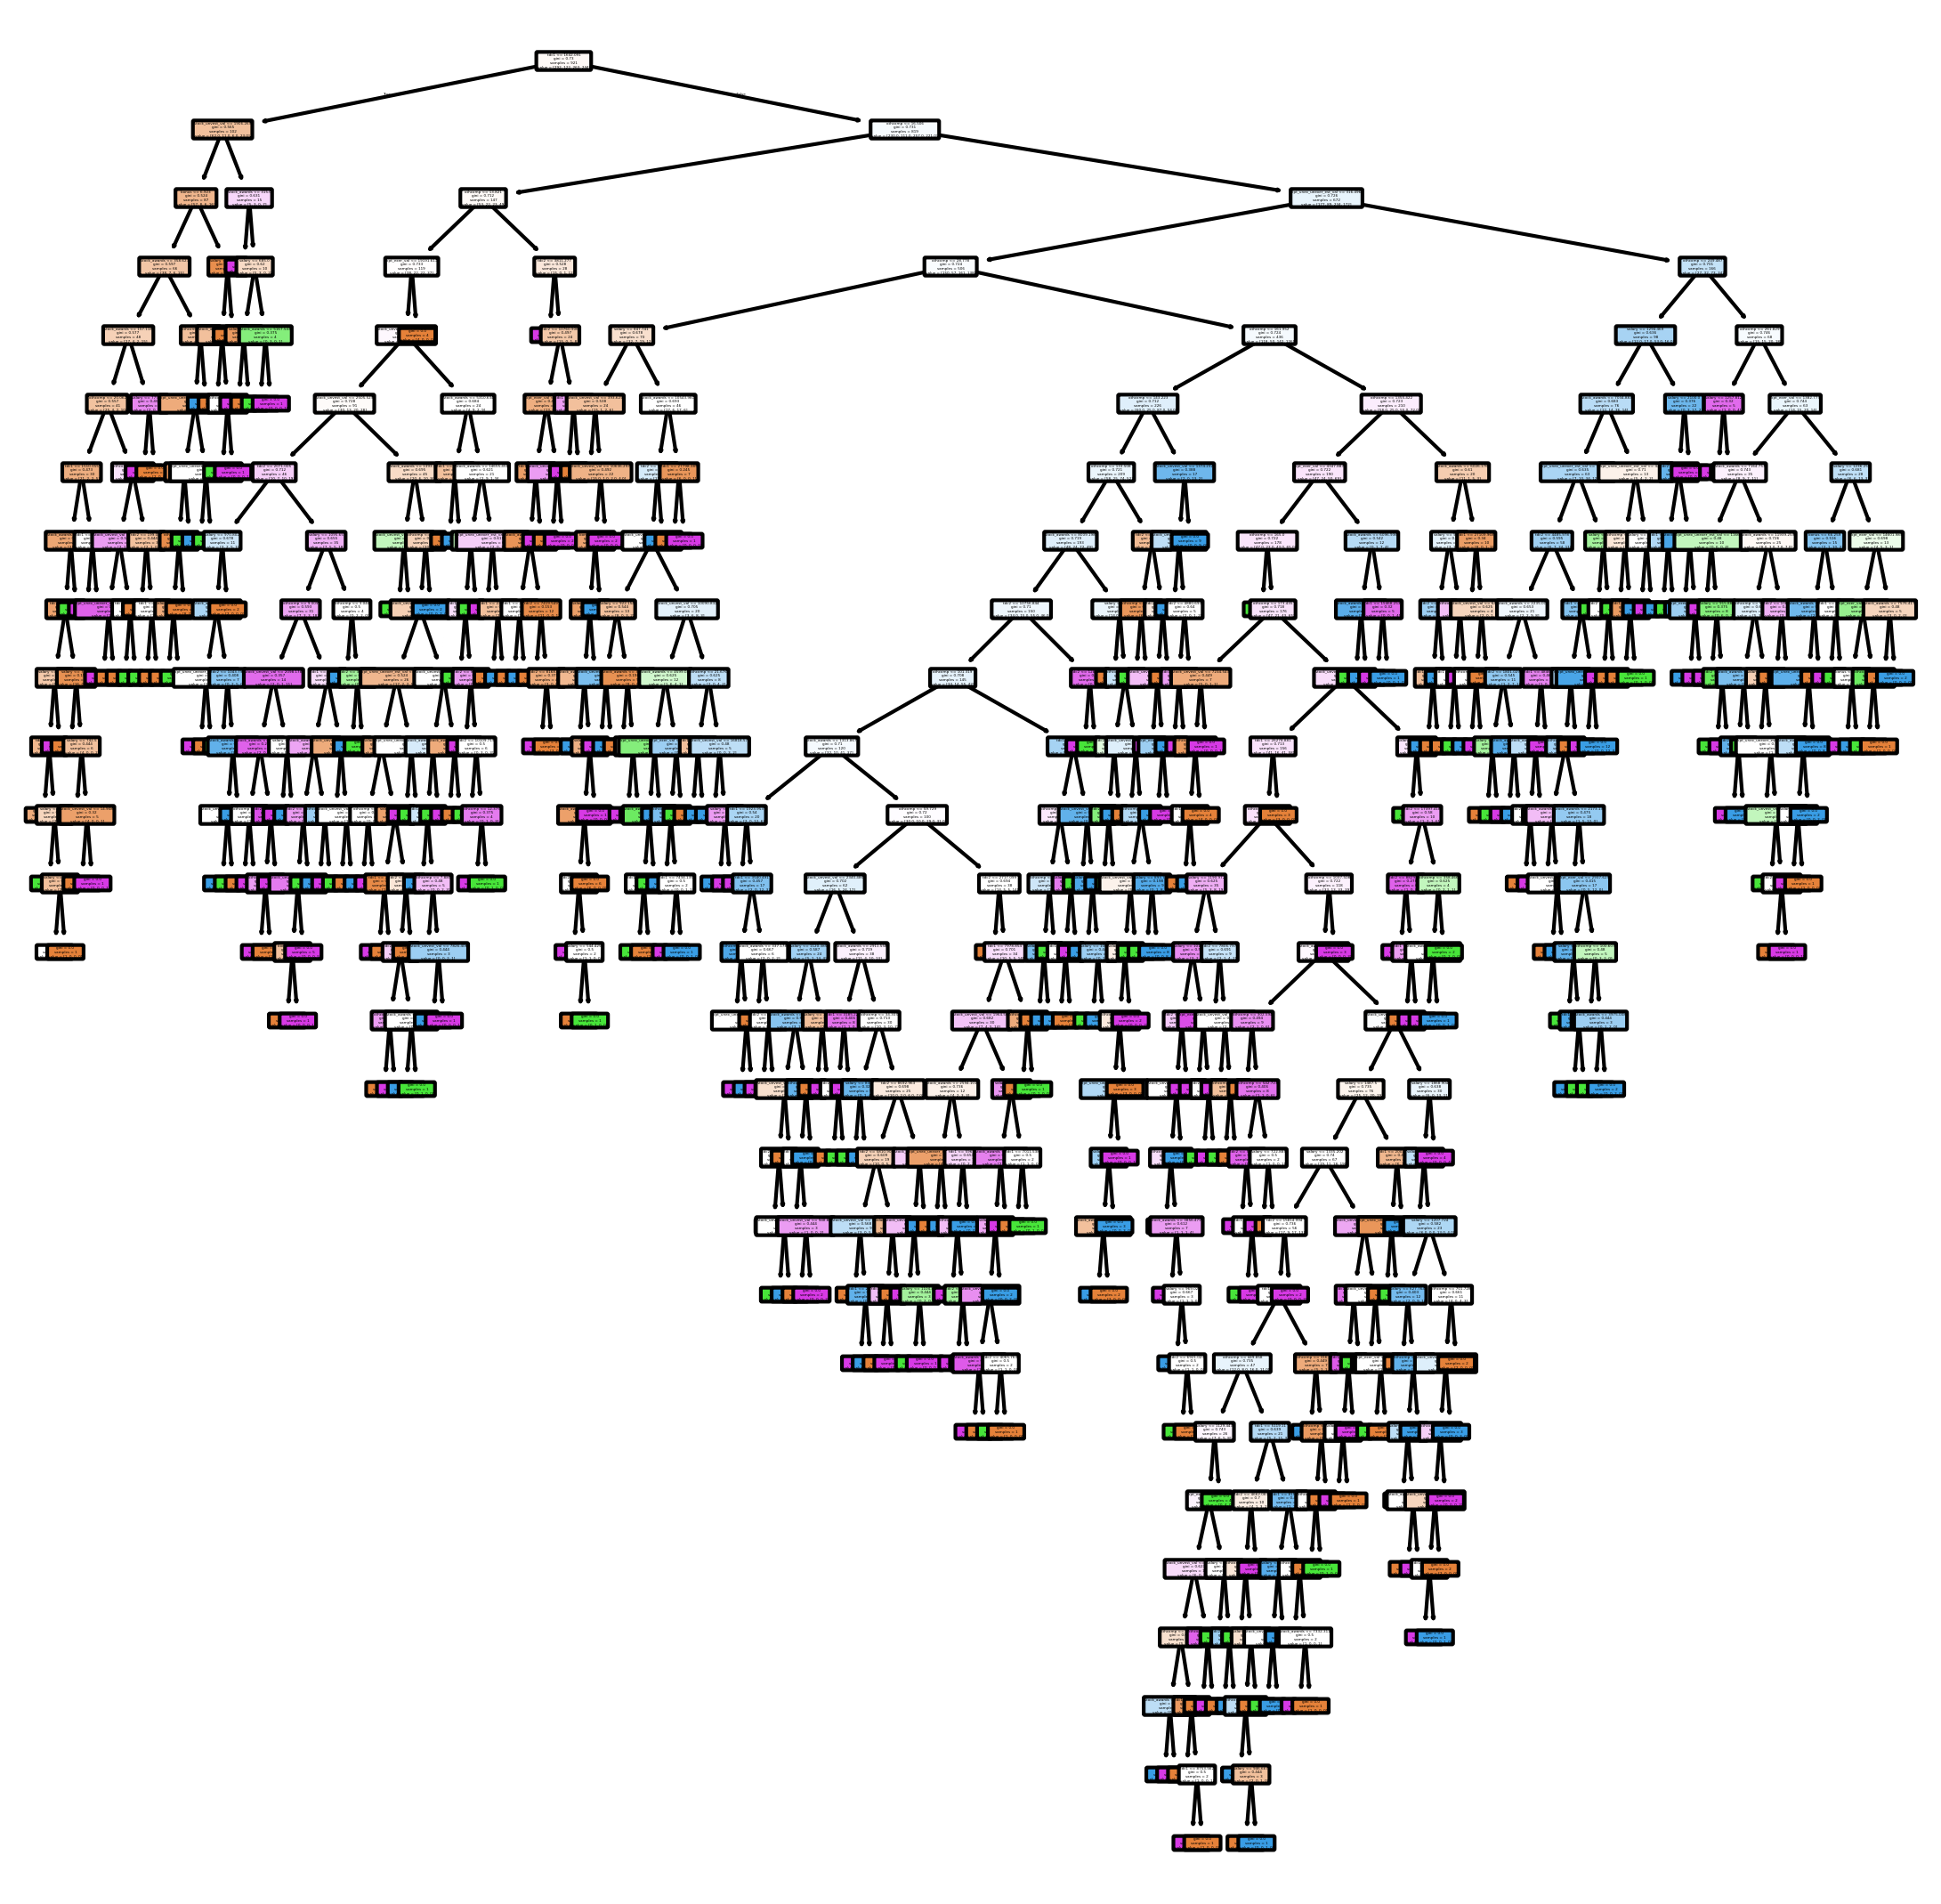

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,9), dpi = 300)
tree.plot_tree(model, feature_names = features, filled = True, rounded = True)
plt.show()

In [10]:
# Need to prune the tree
# use the training data to find the all possibile parameters for training tree (ccp_alpha)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas

array([0.        , 0.00036193, 0.00081433, 0.00081433, 0.00088219,
       0.00090481, 0.00090481, 0.00090481, 0.00090481, 0.00090481,
       0.00090481, 0.00090481, 0.00090481, 0.00093067, 0.00093067,
       0.00095005, 0.00096513, 0.00096944, 0.00098707, 0.00098707,
       0.00098707, 0.00099529, 0.00100226, 0.00108578, 0.00108578,
       0.00108578, 0.00108578, 0.00108578, 0.00108578, 0.00108578,
       0.00108578, 0.00108578, 0.00108578, 0.00108578, 0.00108578,
       0.00108578, 0.00108578, 0.00108578, 0.00108578, 0.00108578,
       0.00108578, 0.00108578, 0.00108578, 0.00108578, 0.00108578,
       0.00108578, 0.00108578, 0.00108578, 0.00108578, 0.00108578,
       0.00108578, 0.00108578, 0.00108578, 0.0011461 , 0.00120642,
       0.00124089, 0.00124089, 0.00124089, 0.00125851, 0.00129259,
       0.0012969 , 0.00130293, 0.00130293, 0.00130293, 0.00130293,
       0.00130293, 0.00130293, 0.00131436, 0.00133254, 0.00135722,
       0.00137532, 0.001396  , 0.00141151, 0.00141151, 0.00143

In [11]:
# Build models with each of these parameters as cost_complexity function reported
model = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    model.append(clf)
print("Number of nodes in the last tree: {} with ccp_alpha is {}".format(
      model[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree: 1 with ccp_alpha is 0.017203414934581218


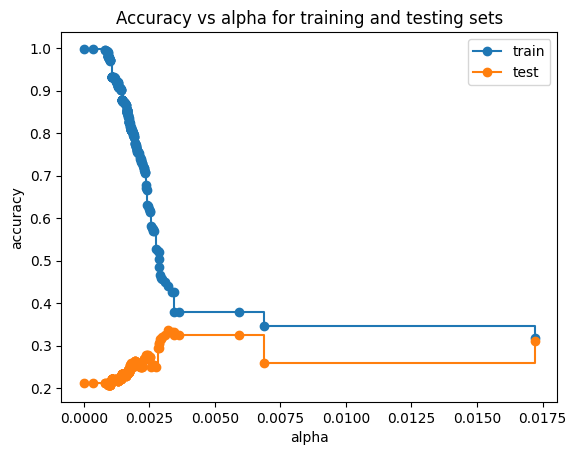

In [12]:
# compare the training and test scores for each of the models
train_scores = [models.score(X_train, y_train) for models in model]
test_scores = [models.score(X_test, y_test) for models in model]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [13]:
# training our classifier with best ccp_alpha (ccp_alpha where the test and train score are similar, ~.003)
clf = DecisionTreeClassifier(random_state=0, ccp_alpha=0.003)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [14]:
# report the classification accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.3203463203463203


[Text(0.3888888888888889, 0.9615384615384616, 'tdc1 <= 1642.091\ngini = 0.73\nsamples = 921\nvalue = [292, 122, 263, 244]'),
 Text(0.1111111111111111, 0.8846153846153846, 'stock_unvest_val <= 1906.269\ngini = 0.565\nsamples = 102\nvalue = [62.0, 11.0, 6.0, 23.0]'),
 Text(0.25, 0.9230769230769231, 'True  '),
 Text(0.05555555555555555, 0.8076923076923077, 'gini = 0.524\nsamples = 87\nvalue = [57, 8, 6, 16]'),
 Text(0.16666666666666666, 0.8076923076923077, 'stock_awards <= 315.0\ngini = 0.631\nsamples = 15\nvalue = [5, 3, 0, 7]'),
 Text(0.1111111111111111, 0.7307692307692307, 'gini = 0.0\nsamples = 5\nvalue = [0, 0, 0, 5]'),
 Text(0.2222222222222222, 0.7307692307692307, 'salary <= 685.0\ngini = 0.62\nsamples = 10\nvalue = [5, 3, 0, 2]'),
 Text(0.16666666666666666, 0.6538461538461539, 'gini = 0.278\nsamples = 6\nvalue = [5, 0, 0, 1]'),
 Text(0.2777777777777778, 0.6538461538461539, 'gini = 0.375\nsamples = 4\nvalue = [0, 3, 0, 1]'),
 Text(0.6666666666666666, 0.8846153846153846, 'othcomp <= 

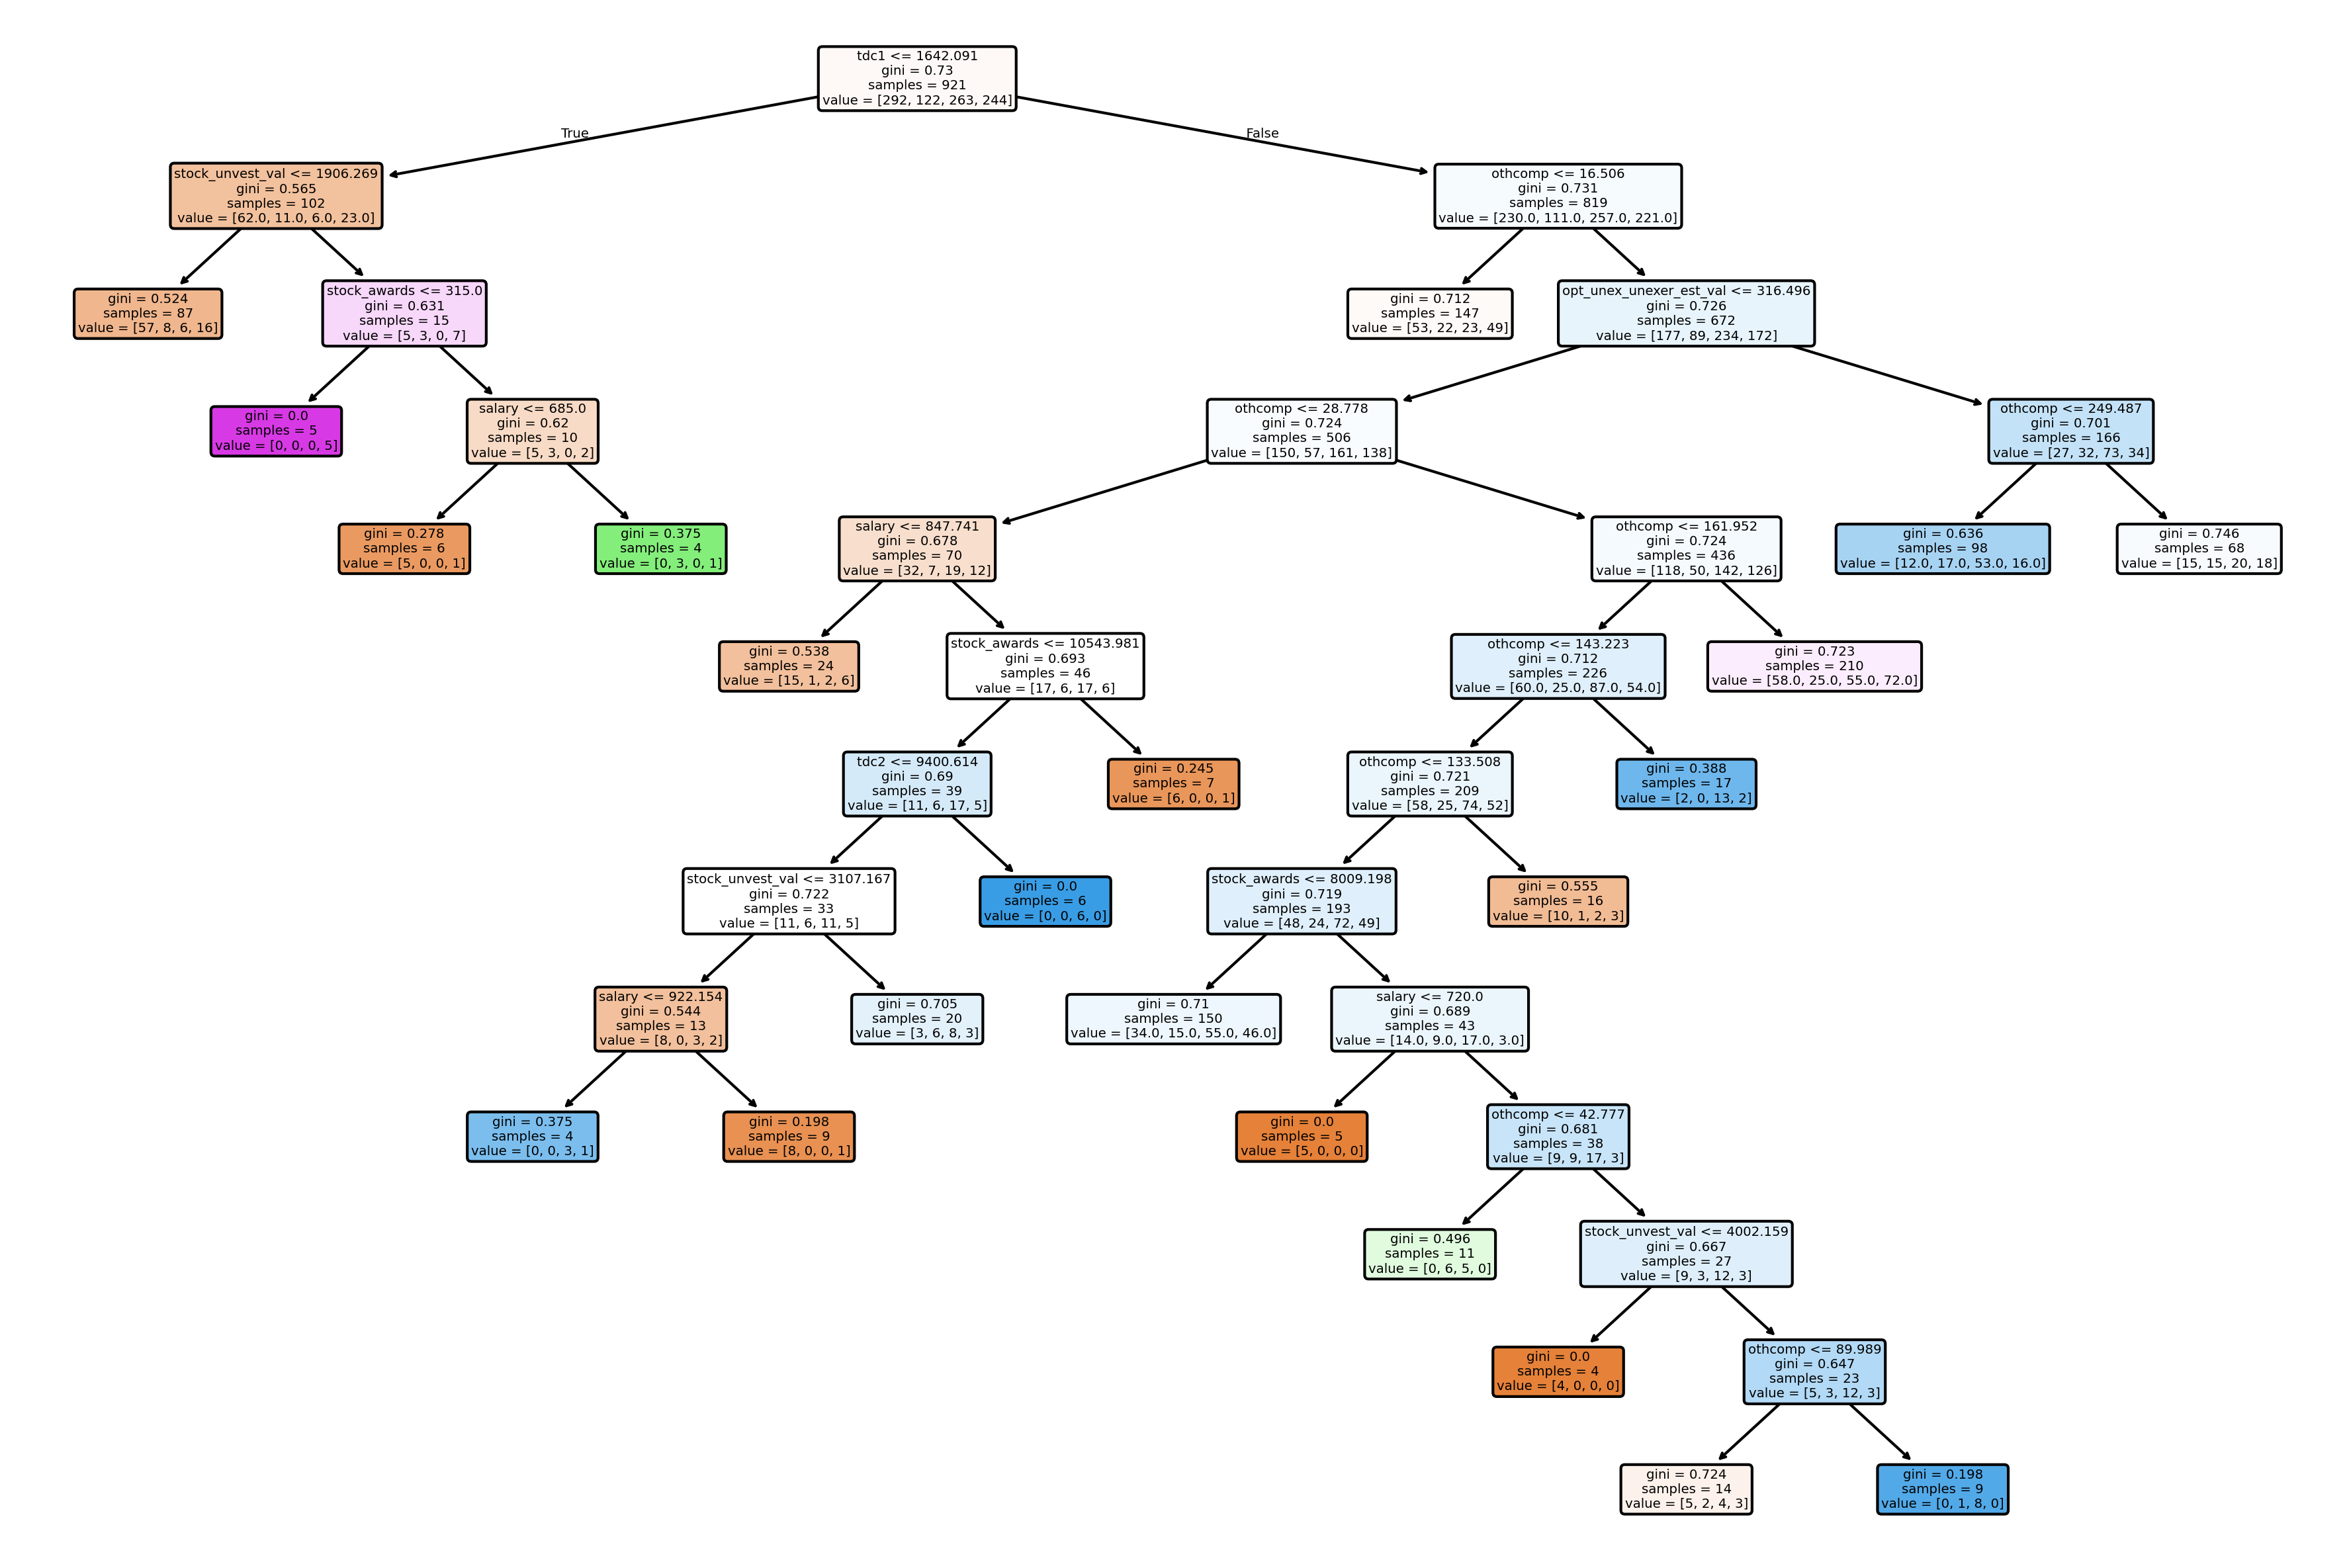

In [15]:
# plot tree to check if the size reduced
plt.figure(figsize=(15,10), dpi= 300)
tree.plot_tree(clf, feature_names = features, filled = True, rounded = True)

## Decision Tree Regressor

In [16]:
# Select the compensation variables to be used in regression
features = ["bonus", "opt_exer_val", "opt_unex_unexer_est_val", "othcomp", "salary", "stock_awards", "stock_unvest_val", "tdc1", "tdc2"]
X = fullData[features].values
y = fullData['Total Income Taxes as % of pretax income'].values

X.shape

(1152, 9)

In [17]:
# Split into test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.tree import DecisionTreeRegressor
# initialize the classifier to uses one of the four options “squared_error”, “friedman_mse”, “absolute_error”, “poisson”
modelRegressor = DecisionTreeRegressor(criterion='squared_error', min_samples_split=5, max_depth=5)
# fit the model
modelRegressor.fit(X_train, y_train)
# predict
y_pred = modelRegressor.predict(X_test)

In [19]:
# print the tree
importances = pd.DataFrame({"feature": features,"importance": np.round(modelRegressor.feature_importances_,3)})

importances = importances.sort_values("importance",ascending=False).set_index("feature")
importances

,importance
feature,
opt_unex_unexer_est_val,0.607
tdc2,0.107
salary,0.105
stock_unvest_val,0.097
othcomp,0.073
tdc1,0.010
bonus,0.000
opt_exer_val,0.000
stock_awards,0.000


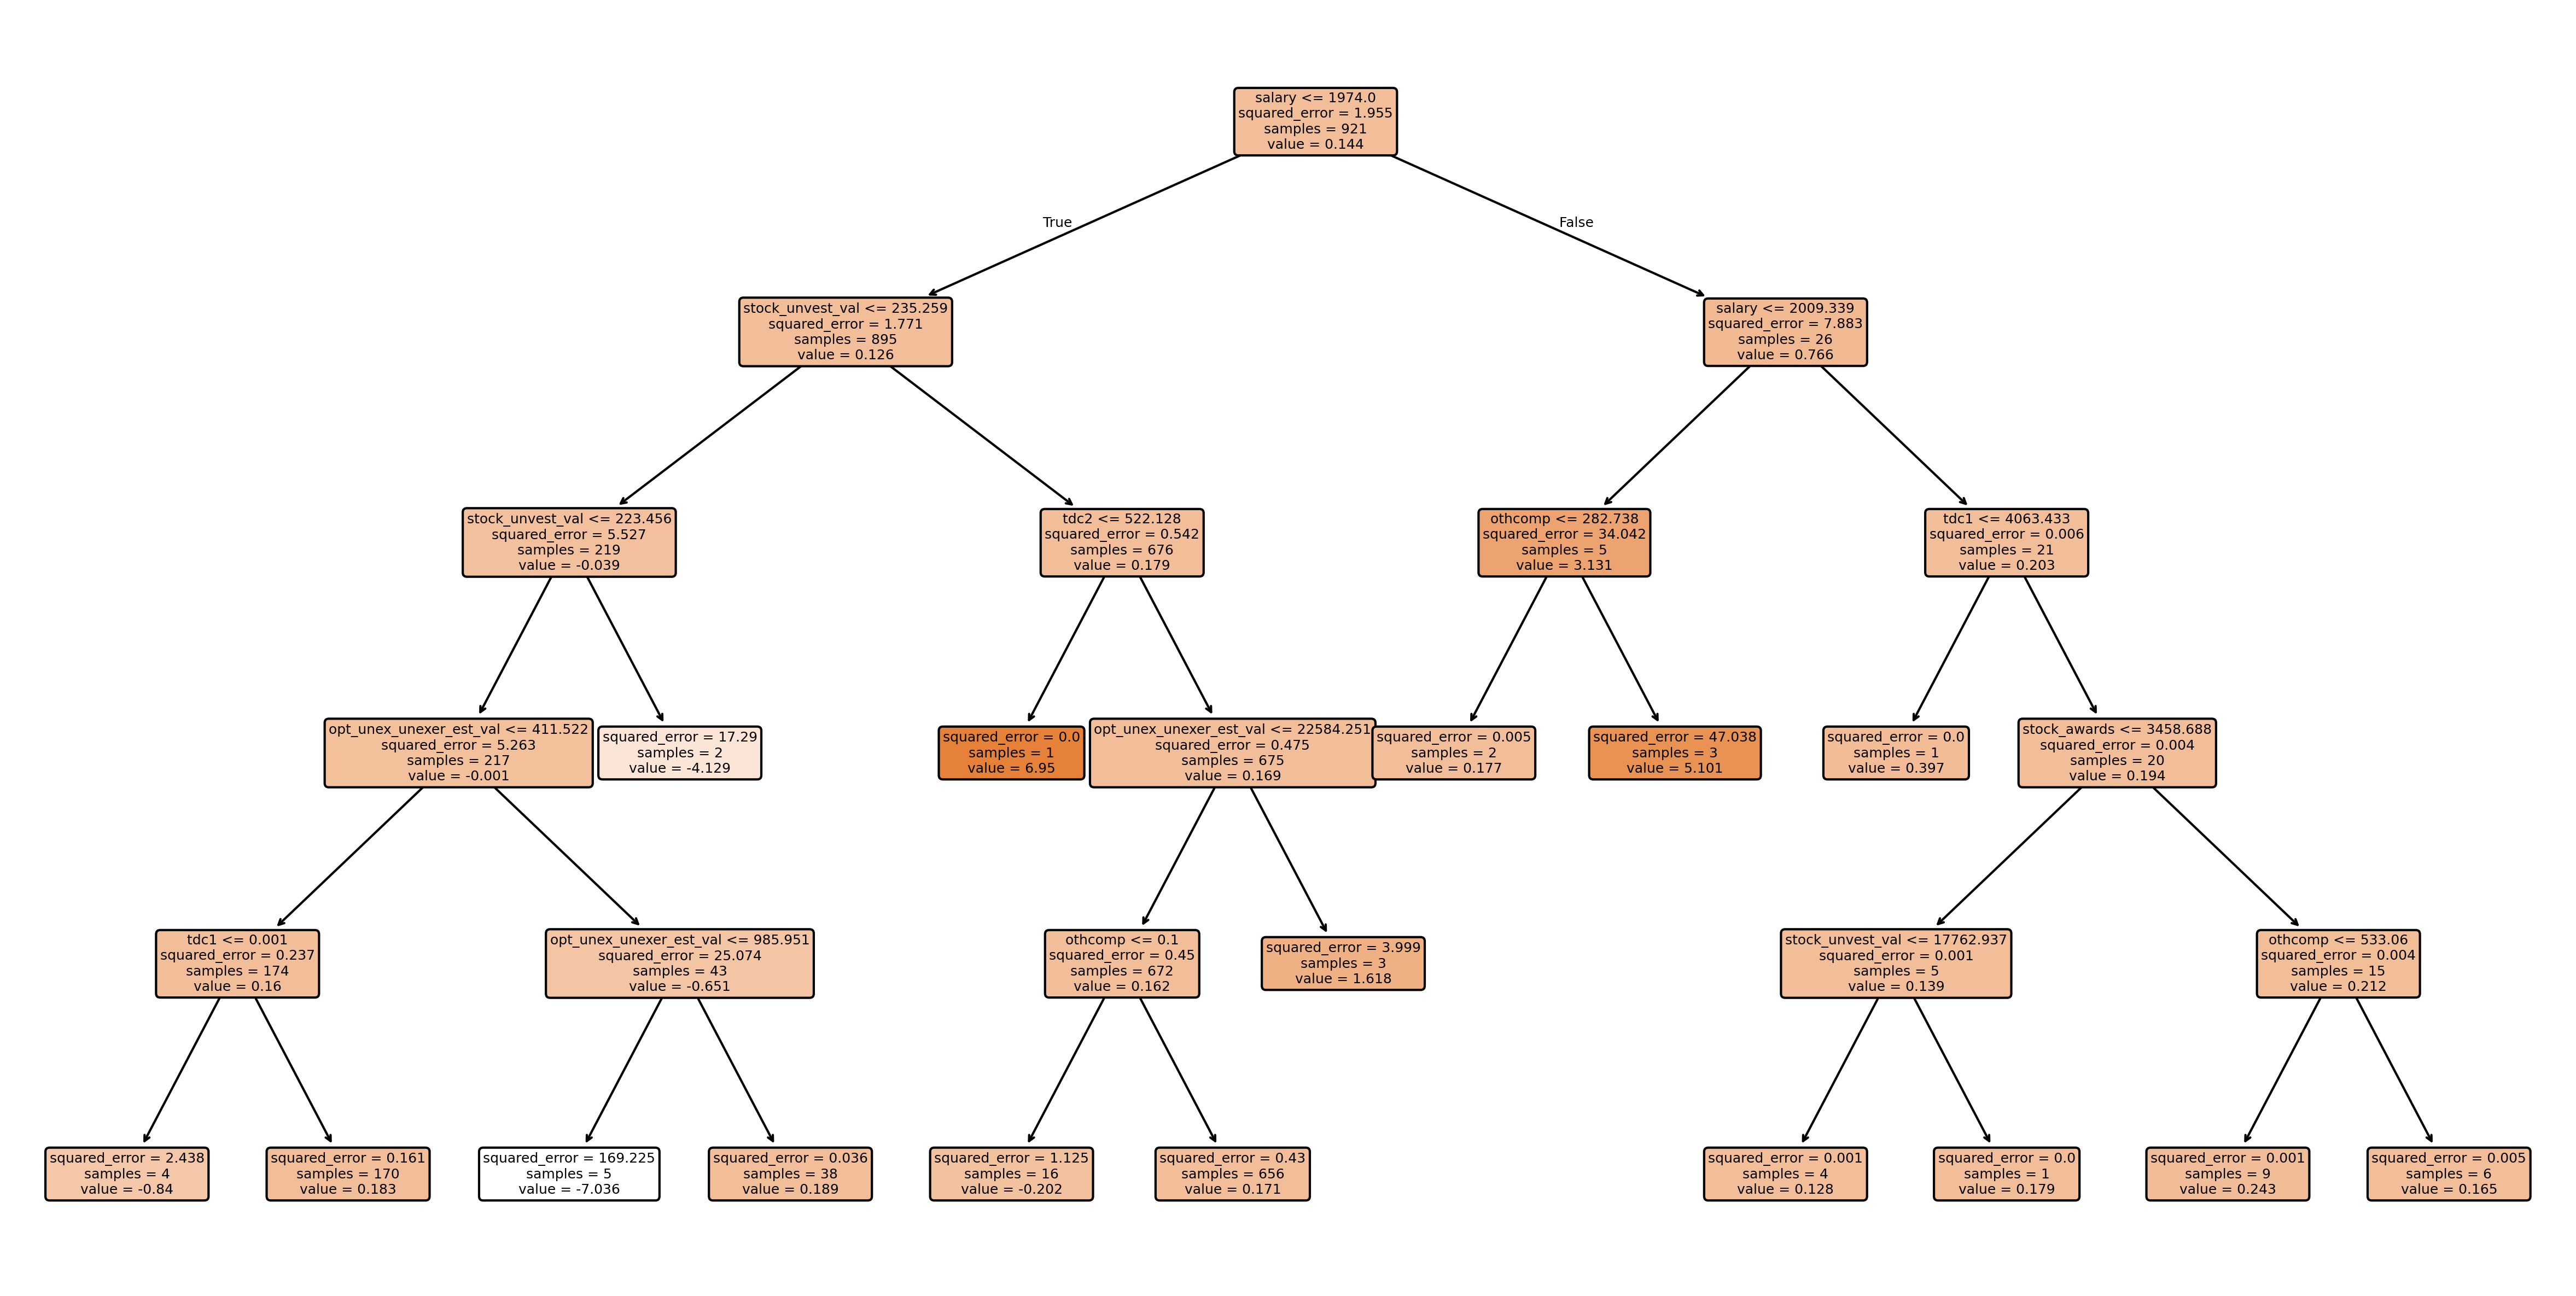

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,10), dpi = 300)
tree.plot_tree(modelRegressor, feature_names = features, filled = True, rounded = True, fontsize=6);

In [24]:
# accuracy and error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")

R-squared: -0.002866139105818899
MSE: 18.208477835708717
MAE: 0.49350807162095484
